# Fuzzy C Means

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving A2-Q1.csv to A2-Q1.csv


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [ ]:
data = pd.read_csv('A2-Q1.csv')

In [ ]:
print(data)

           X0        X1
0    3.728875  3.211032
1    4.493511  1.951484
2   -5.607483 -3.815366
3    3.791209  2.525574
4   -4.756351 -5.422254
..        ...       ...
995 -1.498315  3.035748
996 -3.478058 -3.703015
997  0.954838  2.323962
998  1.334012  0.844458
999  2.895487  0.372568

[1000 rows x 2 columns]


In [ ]:
df = data[['X0','X1']].values

In [ ]:
print(df)

[[ 3.72887503  3.21103234]
 [ 4.49351106  1.95148449]
 [-5.60748323 -3.81536614]
 ...
 [ 0.95483836  2.32396226]
 [ 1.33401192  0.8444582 ]
 [ 2.89548657  0.37256797]]


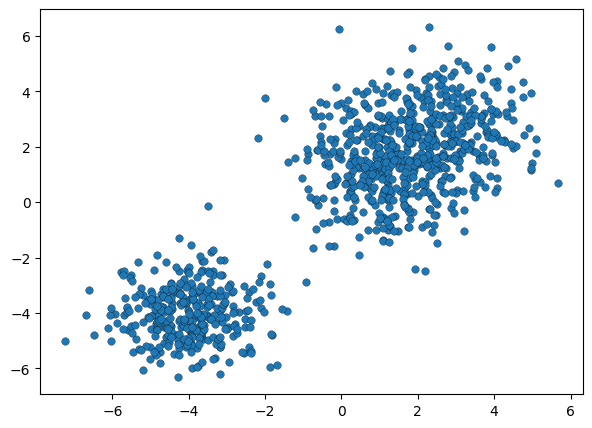

In [ ]:
plt.figure(figsize=(7, 5))
plt.scatter(df[:, 0], df[:, 1], s=30, edgecolors='k', linewidths=0.2)

In [ ]:
def FCM(df, C=3, m=1.618, iters=150, e=1e-6):
    N = len(df)
    U = np.random.dirichlet(np.ones(C), N)

    for i in range(iters):
        U_T = U.T ** m
        centroid = (U_T @ df) / U_T.sum(axis=1, keepdims=True)

        dist = np.array([[np.linalg.norm(x - c)**2 for c in centroid] for x in df])
        dist = np.fmax(dist, 1e-8)

        U_new = 1.0 / np.sum((dist[:, :, None] / dist[:, None, :]) ** (1 / (m - 1)), axis=2)

        if np.linalg.norm(U_new - U) < e:
            break
        U = U_new

    return U, centroid

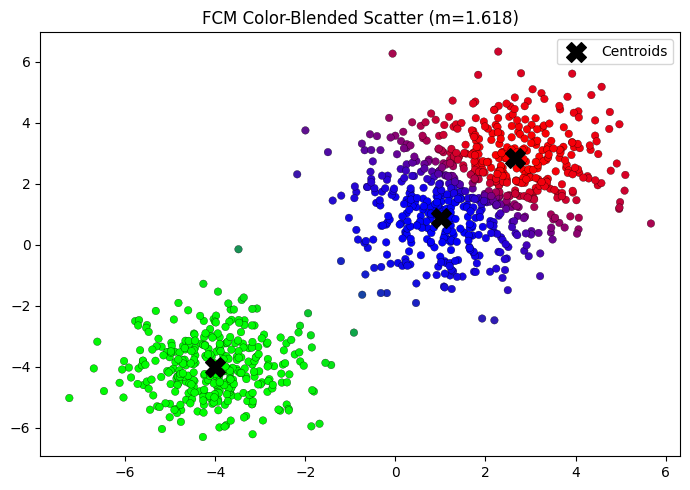

In [ ]:
U, centroids = FCM(df, m=1.618)

cluster_colors = np.array([[1,0,0], [0,1,0], [0,0,1]])
point_colors = U @ cluster_colors
point_colors = np.clip(point_colors, 0, 1)

plt.figure(figsize=(7, 5))
plt.scatter(df[:, 0], df[:, 1], c=point_colors, s=30, edgecolors='k', linewidths=0.2)
plt.scatter(centroids[:, 0], centroids[:, 1], c='black', marker='X', s=200, label='Centroids')
plt.title('FCM Color-Blended Scatter (m=1.618)')
plt.legend()
plt.tight_layout()
plt.show()

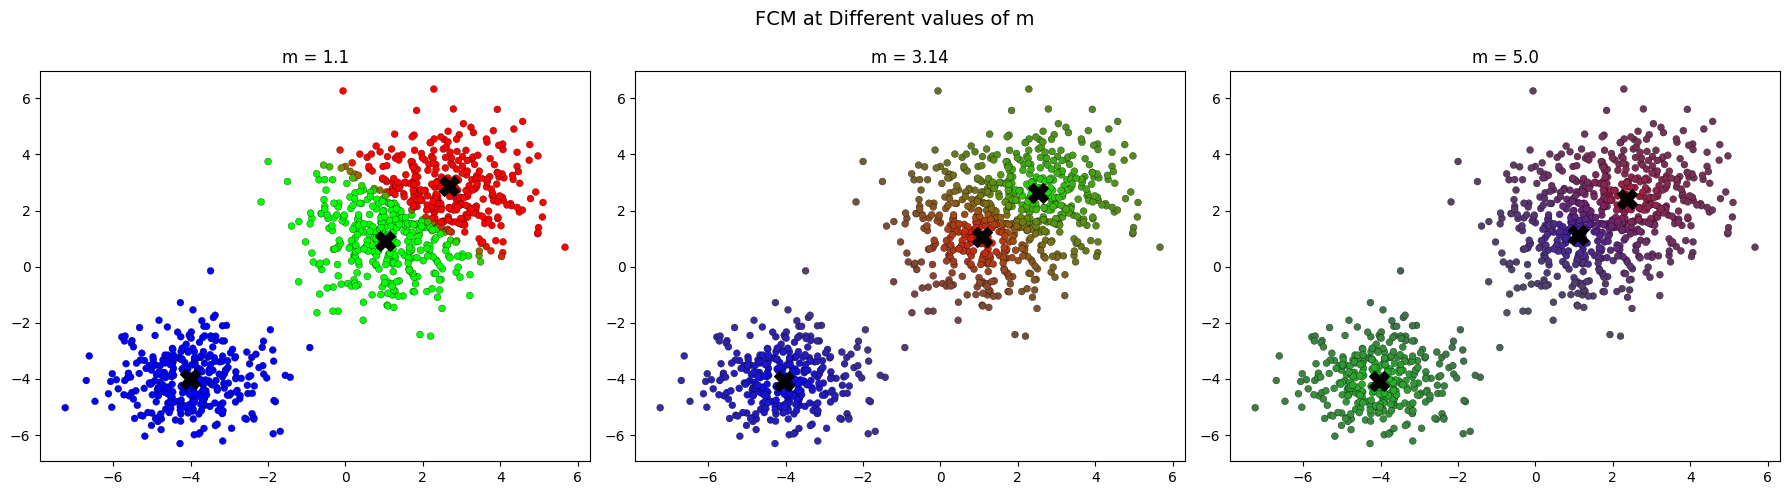

In [ ]:
m_list = [1.1, 3.14, 5.0]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, m_val in zip(axes, m_list):
    U, centroids = FCM(df, m=m_val)
    colors = np.clip(U @ cluster_colors, 0, 1)
    ax.scatter(df[:, 0], df[:, 1], c=colors, s=25, edgecolors='k', linewidths=0.2)
    ax.scatter(centroids[:, 0], centroids[:, 1], c='black', marker='X', s=200)
    ax.set_title(f'm = {m_val}')

plt.suptitle('FCM at Different values of m', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.cluster import KMeans

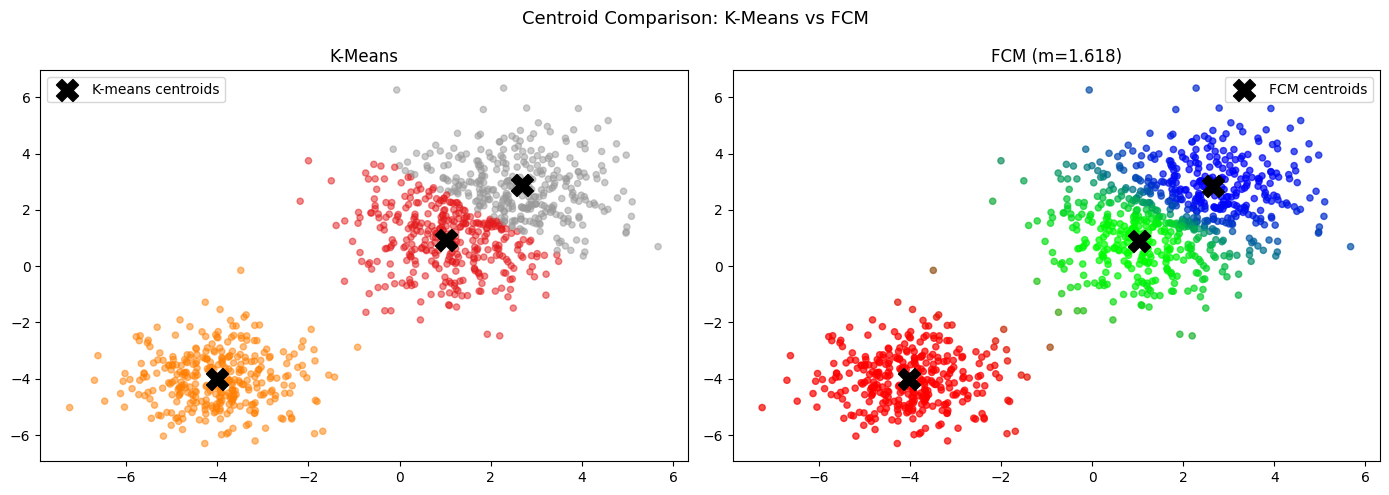

K-Means Centroids:
 [[-4.007 -4.003]
 [ 1.008  0.915]
 [ 2.686  2.87 ]]

FCM Centroids:
 [[-4.017 -4.016]
 [ 1.022  0.88 ]
 [ 2.647  2.847]]

Avg inter-centroid distance — K-Means: 6.397 | FCM: 6.381


In [ ]:
km = KMeans(n_clusters=3, random_state=42, n_init=10).fit(df)
km_centers = km.cluster_centers_

U_fcm, fcm_centers = FCM(df, m=1.618)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(df[:, 0], df[:, 1], c=km.labels_, cmap='Set1', s=20, alpha=0.5)
axes[0].scatter(km_centers[:, 0], km_centers[:, 1], c='black', marker='X', s=250, label='K-means centroids')
axes[0].set_title('K-Means')
axes[0].legend()

colors = np.clip(U_fcm @ cluster_colors, 0, 1)
axes[1].scatter(df[:, 0], df[:, 1], c=colors, s=20, alpha=0.7)
axes[1].scatter(fcm_centers[:, 0], fcm_centers[:, 1], c='black', marker='X', s=250, label='FCM centroids')
axes[1].set_title('FCM (m=1.618)')
axes[1].legend()

plt.suptitle('Centroid Comparison: K-Means vs FCM', fontsize=13)
plt.tight_layout()
plt.show()

print("K-Means Centroids:\n", np.sort(km_centers, axis=0).round(3))
print("\nFCM Centroids:\n", np.sort(fcm_centers, axis=0).round(3))

km_dists = [np.linalg.norm(km_centers[i] - km_centers[j]) for i in range(3) for j in range(i+1, 3)]
fcm_dists = [np.linalg.norm(fcm_centers[i] - fcm_centers[j])for i in range(3) for j in range(i+1, 3)]

print(f"\nAvg inter-centroid distance — K-Means: {np.mean(km_dists):.3f} | FCM: {np.mean(fcm_dists):.3f}")